In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
#from deep_learning_models import TripletNet, identity_loss

2024-06-03 18:48:35.800022: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-03 18:48:37.181095: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-03 18:48:39.797776: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-03 18:48:43.836842: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:



#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/Cropped_data/Device_1/IQ_I_1.rar"
#"/workspaces/work/Dataset/dataset_training_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [4]:

file_path = training_dataset_path        
dev_range = np.arange(0,20, dtype = int), 
pkt_range = np.arange(0,20000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, labels = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

OSError: Unable to synchronously open file (file signature not found)

In [5]:
labels.shape

(20000, 1)

In [6]:
data = awgn(data, snr_range)

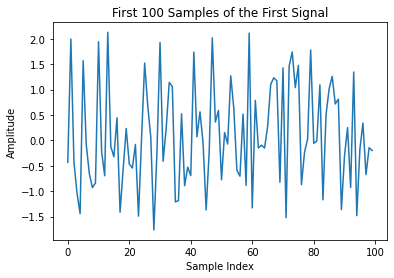

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = np.random.randn(20000, 8192)  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

In [9]:
labels.shape

(20000, 1)

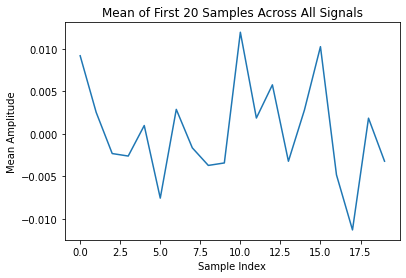

Suspected Preamble: [ 0.00920039  0.00253867 -0.00230499 -0.0025993   0.00099226 -0.00754896
  0.0028924  -0.00163195 -0.00370194 -0.0034107   0.01196618  0.00187331
  0.00577936 -0.00321128  0.0028162   0.01027003 -0.00481242 -0.01128935
  0.00185539 -0.0032059 ]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 20  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 20 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


In [11]:
labels.shape

(20000, 1)

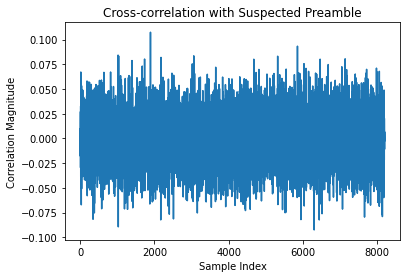

Peak correlation index: 1893
Peak correlation value: 0.10738419397348446
Synchronized signal start index: 1874


In [12]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [14]:
labels.shape

(5000, 1)

In [13]:
import numpy as np

# Given values
peak_index =1893
preamble_length = 20  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [ 2.97179393 -0.5498477   0.97952177  0.8302136  -0.78892317 -1.6785851
  0.00508613  2.47926188  0.45566076 -0.19695152  2.44250147  0.36423054
  0.14531874  1.13971814  0.24898057  2.4596658  -1.44233476 -1.76954633
 -0.20682511  0.17912653]
Synchronized signal start index: 1874


In [14]:
labels.shape

(20000, 1)

In [36]:
#Normalization

#import numpy as np

# Assuming `data` is your (30000, 8192) dataset
#def normalize_data(data):
 #   rms = np.sqrt(np.mean(data**2, axis=1, keepdims=True))
#    return data / rms

# = normalize_data(data)


In [15]:
data.shape

(20000, 8192)

In [16]:
import numpy as np

# Generate example data input (30000, 8192)
data_input = np.random.randn(20000, 8192)

# Known preamble sequence
#preamble = np.array([-1.21610774, 1.94112514, 0.71034659, 1.48957633, -0.96537472, 0.68819186, 0.40421485, -0.98064237, -0.21699215, 0.01402814, 2.20441799, 0.56209869])
preamble=np.array([2.97179393, -0.5498477, 0.97952177, 0.8302136, -0.78892317, -1.6785851, 0.00508613, 2.47926188, 0.45566076, -0.19695152, 2.44250147, 0.36423054, 0.14531874, 1.13971814, 0.24898057, 2.4596658, -1.44233476, -1.76954633, -0.20682511, 0.17912653])




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 2838


In [17]:
import numpy as np

# Generate example data input (30000, 8192)
data_input = np.random.randn(20000, 8192)

# Known preamble sequence
#preamble = np.array([-1.21610774, 1.94112514, 0.71034659, 1.48957633, -0.96537472, 0.68819186, 0.40421485, -0.98064237, -0.21699215, 0.01402814, 2.20441799, 0.56209869])
preamble=np.array([2.97179393, -0.5498477, 0.97952177, 0.8302136, -0.78892317, -1.6785851, 0.00508613, 2.47926188, 0.45566076, -0.19695152, 2.44250147, 0.36423054, 0.14531874, 1.13971814, 0.24898057, 2.4596658, -1.44233476, -1.76954633, -0.20682511, 0.17912653]
)


# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 1237


In [21]:
labels.shape

(5000, 1)

In [18]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
pilot = np.random.randn(len(preamble))

# Generate example data input (30000, 8192)
data_input = np.random.randn(20000, 8192)

# Known preamble sequence
#preamble = np.array([-1.21610774, 1.94112514, 0.71034659, 1.48957633, -0.96537472, 0.68819186, 0.40421485, -0.98064237, -0.21699215, 0.01402814, 2.20441799, 0.56209869])
preamble=np.array(
[2.97179393, -0.5498477, 0.97952177, 0.8302136, -0.78892317, -1.6785851, 0.00508613, 2.47926188, 0.45566076, -0.19695152, 2.44250147, 0.36423054, 0.14531874, 1.13971814, 0.24898057, 2.4596658, -1.44233476, -1.76954633, -0.20682511, 0.17912653]
)
# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


Most Common Synchronization Offset: 5514


In [28]:
train_spectrograms=compensated_data, 
train_labels=labels

In [19]:
ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
 # Convert time-domain IQ samples to channel-independent spectrograms.
data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)

In [20]:
data.shape

(20000, 102, 62, 1)

In [21]:
labels.shape

(20000, 1)

In [65]:
print(data.shape)  # Should output (30000, 8192)


(5000, 102, 62, 1)


In [66]:
labels.shape

(5000, 1)

In [22]:
print(data)

[[[[ 0.52661475]
   [-0.19174478]
   [-0.88584128]
   ...
   [ 0.88321639]
   [-0.91954437]
   [-0.49065432]]

  [[ 1.19667051]
   [-1.25951466]
   [ 1.07339847]
   ...
   [-0.09092115]
   [ 0.4791137 ]
   [ 0.23405365]]

  [[-0.11045639]
   [-1.12603102]
   [ 0.39305513]
   ...
   [ 2.72310411]
   [ 0.12621885]
   [-0.62434006]]

  ...

  [[-0.44383294]
   [ 1.71350963]
   [-0.50728299]
   ...
   [-1.3065885 ]
   [ 1.21369383]
   [-0.61363714]]

  [[-0.11045639]
   [-1.12603102]
   [ 0.39305513]
   ...
   [ 2.72310411]
   [ 0.12621885]
   [-0.62434006]]

  [[ 1.19667051]
   [-1.25951466]
   [ 1.07339847]
   ...
   [-0.09092115]
   [ 0.4791137 ]
   [ 0.23405365]]]


 [[[-1.00001997]
   [ 1.00653307]
   [ 0.36220976]
   ...
   [-0.05884401]
   [-0.81635431]
   [ 0.69329722]]

  [[-0.6060371 ]
   [ 0.08620294]
   [-0.29037306]
   ...
   [-0.36686818]
   [ 0.03466102]
   [ 0.23787805]]

  [[ 0.11498917]
   [ 0.85726364]
   [-0.87228456]
   ...
   [-0.11686955]
   [-0.52741072]
   [ 0.0318

In [27]:
labels.shape

(5000, 1)

In [25]:
data.shape

(20000, 102, 62, 1)

In [72]:
labels.shape[0]

5000

In [69]:
data.shape[1]

102

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Assuming your data is stored in data and labels arrays
# X shape: (20000, 102, 62, 1), y shape: (5000,)
X = data
y = labels

# Step 1: Normalization
X_normalized = X / 255.0  # Assuming pixel values are in the range [0, 255]

# Step 2: Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Step 3: Data Augmentation (Optional)
# Implement data augmentation if needed using Keras ImageDataGenerator

# Step 4: Define the CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(102, 62, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(20, activation='softmax')  # Adjust output size based on your problem
])

# Step 5: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 6: Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=20)
y_val = to_categorical(y_val, num_classes=20)

# Step 7: Train the Model
history = model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_val, y_val))

# Step 8: Evaluate the Model
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


Train on 16000 samples, validate on 4000 samples
Epoch 1/1000
16000/16000 [==============================] - 68s 4ms/step - loss: 2.9963 - acc: 0.0484 - val_loss: 2.9963 - val_acc: 0.0447
Epoch 2/1000
16000/16000 [==============================] - 67s 4ms/step - loss: 2.9961 - acc: 0.0466 - val_loss: 2.9964 - val_acc: 0.0432
Epoch 3/1000
16000/16000 [==============================] - 68s 4ms/step - loss: 2.9960 - acc: 0.0501 - val_loss: 2.9964 - val_acc: 0.0447
Epoch 4/1000
16000/16000 [==============================] - 67s 4ms/step - loss: 2.9960 - acc: 0.0510 - val_loss: 2.9965 - val_acc: 0.0432
Epoch 5/1000
16000/16000 [==============================] - 67s 4ms/step - loss: 2.9959 - acc: 0.0506 - val_loss: 2.9966 - val_acc: 0.0432
Epoch 6/1000
16000/16000 [==============================] - 67s 4ms/step - loss: 2.9960 - acc: 0.0517 - val_loss: 2.9966 - val_acc: 0.0432
Epoch 7/1000
16000/16000 [==============================] - 67s 4ms/step - loss: 2.9960 - acc: 0.0514 - val_loss: 2.9

KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Assuming your data is stored in data and labels arrays
# X shape: (5000, 102, 62, 1), y shape: (5000,)
X = data
y = labels

# Step 1: Normalization
X_normalized = X / 255.0  # Assuming pixel values are in the range [0, 255]

# Step 2: Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Step 3: Data Augmentation (Optional)
# Implement data augmentation if needed using Keras ImageDataGenerator

# Step 4: Define the CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(102, 62, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='sigmoid')  # Adjust output size based on your problem
])

# Step 5: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 6: Train the Model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Step 7: Evaluate the Model
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


# Convert data to float32
normalized_data = normalized_data.astype(np.float32)
labels = labels.astype(np.int32)  # Ensure labels are integer for one-hot encoding



# Reshape data for 1D CNN
normalized_data = normalized_data.reshape(normalized_data.shape[0], normalized_data.shape[1], 1)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(normalized_data, labels, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(normalized_data.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=256, kernel_size=1, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # Changed output layer to softmax
])

# Compile the model
model.compile(optimizer=Adam(lr=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping, reduce_lr])

# Evaluate the model
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Convert data to float32
compensated_data = compensated_data.astype(np.float32)
labels = labels.astype(np.float32)

# Reshape data for 1D CNN
compensated_data = compensated_data.reshape(compensated_data.shape[0], compensated_data.shape[1], 1)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(compensated_data, labels, test_size=0.2, random_state=42)

# Define the model
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(compensated_data.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=1, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=256, kernel_size=1, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-2), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping, reduce_lr])

# Evaluate the model
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')
